In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall

# Helper Functions

In [2]:
@njit(parallel=True)
def ComputeSNR(S_original, S_noisy):
    """
    Calculate the Signal-to-Noise Ratio (SNR) for each source channel.
    
    Args:
        S_original (ndarray): Ground truth source matrix of shape (n_sources, n_samples).
        S_noisy (ndarray): Estimated or noisy source matrix of shape (n_sources, n_samples).
        
    Returns:
        ndarray: SNR values in decibels (dB) for each channel.
    """
    # Residual noise calculation
    N_hat = S_original - S_noisy
    
    # Power calculation per channel (sum of squares)
    N_P = (N_hat**2).sum(axis=1)
    S_P = (S_original**2).sum(axis=1)
    
    # Standard SNR formula in log scale
    snr = 10 * np.log10(S_P / N_P)
    return snr

def outer_prod_broadcasting(A, B):
    """
    Compute the pairwise outer product between columns of two matrices using broadcasting.
    
    This is used to efficiently calculate cross-correlation terms across all channel pairs.
    """
    return A[..., None] * B[:, None]

def find_permutation_between_source_and_estimation(S, Y):
    """
    Identify the best 1-to-1 mapping between estimated outputs and ground truth sources.
    
    BSS algorithms suffer from permutation ambiguity. This function uses the Pearson 
    correlation absolute values to find which output corresponds to which source.

    Args:
        S (ndarray): Original source matrix (n_sources, n_samples).
        Y (ndarray): Estimated source matrix (n_sources, n_samples).

    Returns:
        ndarray: Indices of Y that best match the order of S.
    """
    # Calculate pairwise correlation using broadcasting trick
    # We normalize by the norms to get the correlation coefficient
    correlation_numerator = np.abs(outer_prod_broadcasting(Y.T, S.T).sum(axis=0))
    normalization = (np.linalg.norm(S, axis=1) * np.linalg.norm(Y, axis=1))
    
    # Find the index of the estimate with the highest correlation for each source
    perm = np.argmax(correlation_numerator / normalization, axis=0)
    return perm

def signed_and_permutation_corrected_sources(S, Y):
    """
    Correct for both permutation and sign ambiguity in the estimated sources.
    
    In ICA/BSS, the output Y_i could be -S_j. This function reorders Y and flips
    the signs so that the output matches the ground truth S as closely as possible.

    Args:
        S (ndarray): Ground truth source matrix (n_sources, n_samples).
        Y (ndarray): Uncorrected estimation matrix (n_sources, n_samples).

    Returns:
        ndarray: Reordered and sign-flipped estimations.
    """
    # 1. Find the permutation (mapping)
    perm = find_permutation_between_source_and_estimation(S, Y)
    
    # 2. Determine the sign by looking at the dot product of the matched pairs
    # If the dot product is negative, we need to flip the sign (multiply by -1)
    matched_Y = Y[perm, :]
    signs = np.sign((matched_Y * S).sum(axis=1))
    
    return signs[:, np.newaxis] * matched_Y

@njit
def ComputeSINR(S, Y):
    """
    Calculate the Signal-to-Interference-plus-Noise Ratio (SINR) in dB.
    
    This function performs internal Z-score normalization to handle scale ambiguity,
    corrects for permutation/sign via correlation, and computes the ratio of 
    signal power to reconstruction error.

    Args:
        S (ndarray): Ground truth source matrix.
        Y (ndarray): Estimated source matrix.

    Returns:
        float: The aggregate SINR value in dB.
    """
    N_Sources = S.shape[0]
    
    # Numba-friendly normalization: avoid keepdims which is not fully supported
    S_normalized = np.zeros_like(S)
    Y_normalized = np.zeros_like(Y)
    
    for i in range(N_Sources):
        # Subtract mean and divide by std (Z-score) for both S and Y
        s_i = S[i, :]
        S_normalized[i, :] = (s_i - np.mean(s_i)) / (np.std(s_i) + 1e-9)
        
        y_i = Y[i, :]
        Y_normalized[i, :] = (y_i - np.mean(y_i)) / (np.std(y_i) + 1e-9)
        
    # Compute the correlation matrix between all pairs
    corr = np.dot(Y_normalized, S_normalized.T) 
    
    # Solve permutation ambiguity: find which Y index matches which S index
    perm = np.zeros(N_Sources, dtype=np.int64)
    for i in range(N_Sources):
        perm[i] = np.argmax(np.abs(corr[:, i]))
        
    # Solve sign ambiguity: check if the matched signals are inverted
    signs = np.zeros((N_Sources, 1))
    for i in range(N_Sources):
        signs[i, 0] = np.sign(corr[perm[i], i])
    
    # Create the corrected estimate (aligned with S)
    Y_corrected = signs * Y[perm, :]
    
    # Calculate the error (Interference + Noise)
    E = Y_corrected - S
    
    # Calculate final SINR using Frobenius norms
    MSE = np.linalg.norm(E) ** 2
    SigPow = np.linalg.norm(S) ** 2
    
    sinr_val = 10 * np.log10(SigPow / (MSE + 1e-9))
    return sinr_val

# Generate Sources and Mix Them (4 by 2 case)

In [3]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 3
NumberofMixtures = NumberofSources + 2

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -4, max_val = 4)
S = ProjectRowstoL1NormBall(S.T).T 
S = S * (S >= 0)

print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  3316257
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.993363283233997


(array([0.10363975, 0.10345606, 0.10338638]),
 array([0.16950021, 0.49262125, 0.2363393 , 0.79972876, 0.99074058]))

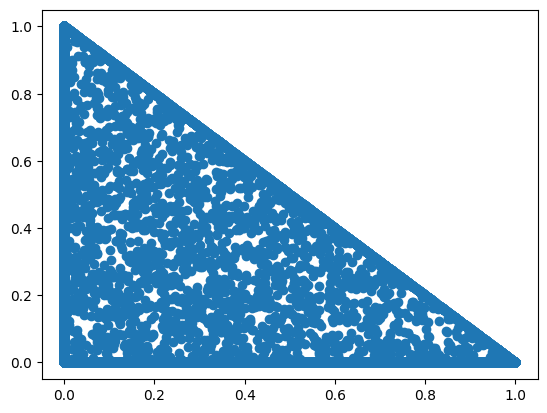

In [4]:
plt.scatter(S[0, :], S[1, :])

# Neural Network Implementation

In [5]:
@njit
def run_neural_dynamics(x, y,
                        W, C_y, mu_y,
                        gamma_predictive,
                        neural_dynamics_iterations,
                        neural_lr_start,
                        neural_lr_stop,
                        stlambd_lr = 0.5,
                        neural_OUTPUT_COMP_TOL=1e-7):
    """
    Perform activity relaxation (inference) to find the optimal neural state 'y'.
    
    This function implements a fast-timescale gradient descent on the network 
    energy function. It balances two primary forces:
    1. Predictive Coding: Minimizing the error between the current state and 
       the feedforward input (y - Wx).
    2. Lateral Inhibition: Minimizing correlation 
       between neurons using a second-order Taylor approximation of the 
       log-determinant objective.

    Args:
        x (ndarray): Input signal vector.
        y (ndarray): Current neural activity vector (initial guess).
        W (ndarray): Feedforward weight matrix.
        C_y (ndarray): Lateral weight matrix (representing covariance/correlation).
        gamma_predictive (float): Weighting factor for the predictive error term.
        neural_dynamics_iterations (int): Maximum steps for activity relaxation.
        neural_lr_start (float): Initial step size for activity updates.
        neural_lr_stop (float): Minimum floor for the decaying step size.
        neural_OUTPUT_COMP_TOL (float): Convergence threshold for early exit.

    Returns:
        ndarray: The relaxed neural activity vector 'y'.
    """
    STLAMBD = 0
    dval = 0
    # Pre-calculate the feedforward drive (projection of input into latent space)
    yke = np.dot(W, x)
    
    # Extract diagonal (variances) and off-diagonal (covariances) from L
    D_y = np.diag(C_y)
    O_y = C_y - np.diag(D_y)
    
    
    for j in range(neural_dynamics_iterations):
        # Time-decaying step size (simulating cooling or annealing)
        lr_y = max(neural_lr_start / (j + 1), neural_lr_stop)
        y_old = y.copy()
        
        # 1. Predictive Error Term: Measures mismatch between activity and input
        error = y - yke

        y_bar = y - mu_y
        # 2. Lateral Term: Implements normalized decorrelation
        lateral = (np.dot(O_y, y_bar / D_y) - y_bar) / D_y
        
        # Combine gradients: Total force acting on the neural state
        grady = gamma_predictive * error + lateral
        
        # Gradient descent step
        y = y - lr_y * grady
        
        # Biological constraint: Firing rates are often bounded (activation function)
        # SOFT THRESHOLDING
        y = np.maximum(y - STLAMBD, 0)

        dval = np.sum(y) - 1
        STLAMBD = max(STLAMBD + stlambd_lr * dval, 0)
        
        # Convergence check: Exit if the activity has stabilized
        if np.linalg.norm(y - y_old) < neural_OUTPUT_COMP_TOL * np.linalg.norm(y):
            break
            
    return y

# Hyperparameters

In [6]:
C_y = 0.2 * np.eye(NumberofSources, NumberofSources)
W = np.eye(NumberofSources, NumberofMixtures) + np.random.randn(NumberofSources, NumberofMixtures) * 0.01
mu_y = np.zeros(NumberofSources)

gamma_predictive = 100
muW = 30 * 1e-2
synaptic_lr_decay_divider=1000
lambda_lateral = 1 - 0.01

neural_lr_start = 0.05
neural_lr_stop = 1e-4
neural_dynamics_iterations = 100
debug_iteration_point = 10000

n_epochs = 1

# Training

In [7]:
samples = N
# idx = np.random.permutation(samples)  # random permutation. Probably not very helpful!
idx = np.arange(X.shape[1])
for epoch_idx in range(n_epochs):
    print("Epoch {} is running".format(epoch_idx))
    for i_sample in tqdm(range(samples)):
        if ((i_sample % debug_iteration_point) == 0) | (
                            i_sample == samples - 1
                        ):
            Y_ = W @ X
            Y_ = signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
            coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
            Y_ = coef_ * Y_
    
            print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(ComputeSINR(S, Y_)))
            print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(ComputeSNR(S, Y_)))
        x_current = X[:, idx[i_sample]]
        y = np.zeros(NumberofSources)

        # y = W @ x_current  # THIS INITIALIZATION DOES NOT HELP AT ALL! ZERO INITIALIZATION WORKS THE BEST
        y = run_neural_dynamics(x_current, y, 
                                W, C_y, mu_y,
                                gamma_predictive,
                                neural_dynamics_iterations, neural_lr_start, neural_lr_stop)
        e = y - W @ x_current
        muW_ = np.max(
                    [
                        muW
                        / (1 + np.log(2 + (i_sample // synaptic_lr_decay_divider))),
                        1e-8,
                    ]
                )
    
        W = W + muW_ * np.outer(e, x_current)
        mu_y = lambda_lateral * mu_y + (1 - lambda_lateral) * y
        y_bar = y - mu_y
        C_y = lambda_lateral * C_y + (1 - lambda_lateral) * np.outer(y_bar, y_bar)

Epoch 0 is running


  0%|          | 0/100000 [00:00<?, ?it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 1.1973339784053405
Component Signal-to-Noise-Ratio (SNR) Values : [ 0.33847274 11.61351794 19.28742114]



/tmp/ipykernel_1485665/1522459025.py:38: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  yke = np.dot(W, x)
 11%|█         | 10857/100000 [00:10<00:17, 5151.51it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 25.513898454435832
Component Signal-to-Noise-Ratio (SNR) Values : [24.80648021 27.74622175 24.63392377]



...

Signal-to-Interference-and-Noise-Ratio (SINR): 28.342084063106366
Component Signal-to-Noise-Ratio (SNR) Values : [27.84486998 26.23003444 34.32685487]



 91%|█████████ | 90821/100000 [00:25<00:01, 5263.10it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 28.54800550499408
Component Signal-to-Noise-Ratio (SNR) Values : [27.79763266 26.66571055 34.25996317]



100%|██████████| 100000/100000 [00:27<00:00, 3662.10it/s]

Signal-to-Interference-and-Noise-Ratio (SINR): 29.13519961486459
Component Signal-to-Noise-Ratio (SNR) Values : [27.00989463 29.17377382 33.38237523]



In [8]:
display_matrix(C_y)

<IPython.core.display.Math object>

In [9]:
display_matrix(mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [10]:
display_matrix(W)

<IPython.core.display.Math object>

In [11]:
Y_ = W @ X
Y_ = signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 29.129568156434672
Component Signal-to-Noise-Ratio (SNR) Values : [27.02021319 29.15357476 33.38831298]



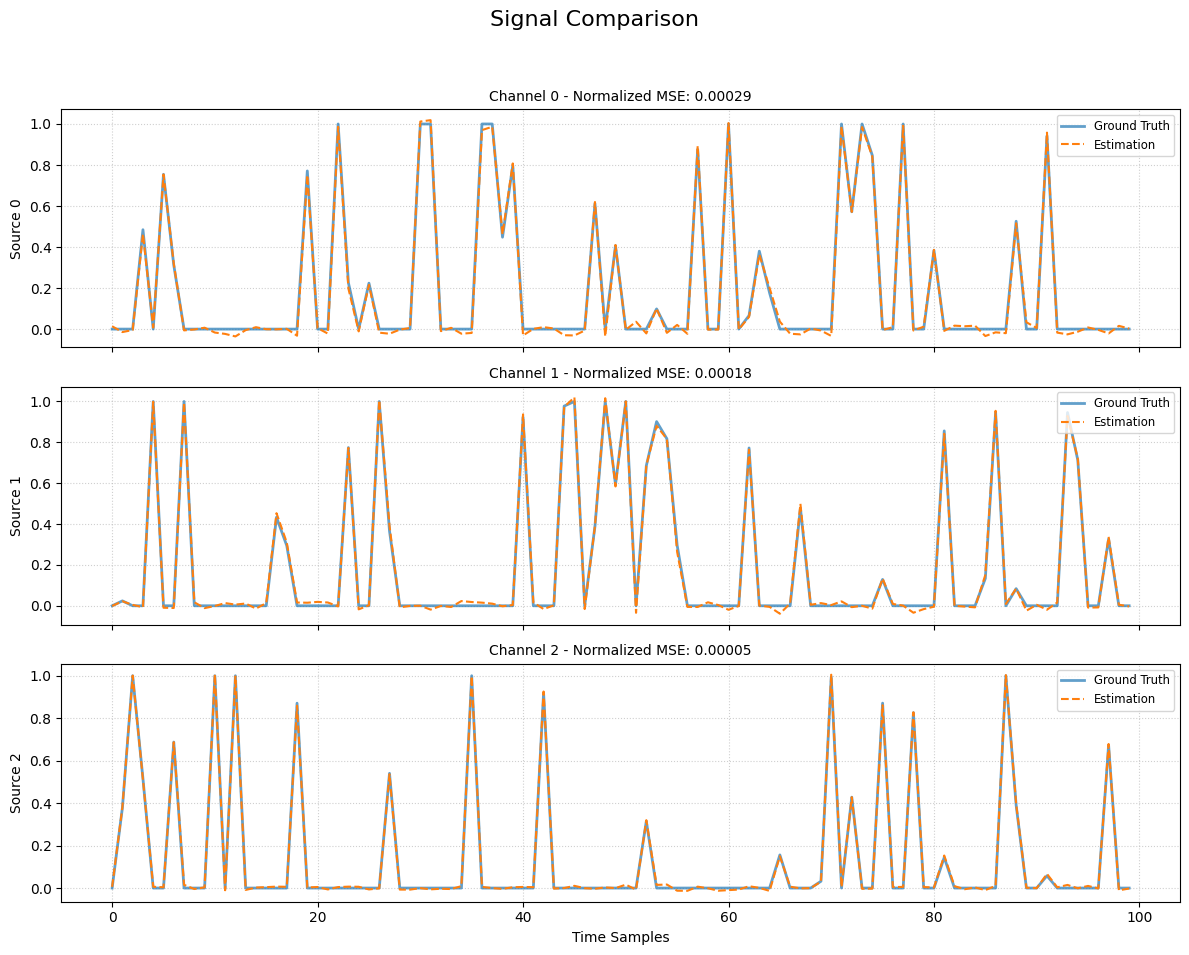

In [12]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])